In [44]:
import numpy as np
import h5py
import pandas as pd
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt


In [89]:


train_dataset = h5py.File('/home/dikshant/projects/ml-fundamentals-pytorch/Dataset/train_catvnoncat.h5', "r")
test_dataset=h5py.File('/home/dikshant/projects/ml-fundamentals-pytorch/Dataset/test_catvnoncat.h5', "r")

X_train=np.array(train_dataset['train_set_x'])
y_train=np.array(train_dataset['train_set_y'])

X_train_original=X_train.copy()
X_test_original=X_test.copy()

X_test=np.array(test_dataset['test_set_x'])
y_test=np.array(test_dataset['test_set_y'])

# Flattening to X with shape (examples,features) and y with (examples,1) basically rows = exampeles and columns only 1.
X_train=X_train.reshape(X_train.shape[0],-1)
X_test=X_test.reshape(X_test.shape[0],-1)
y_train=y_train.reshape(-1,1)
y_test=y_test.reshape(-1,1)

# Normalize by deviding by 255 or sklearn standard scalar, i am using standard scaler as it works for all scenarios

scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)



classes=np.array(test_dataset['list_classes'])

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(classes)
                 

(209, 12288)
(209, 1)
(50, 12288)
(50, 1)
[b'non-cat' b'cat']


In [72]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
def predict_proba(X,w,b):
    return sigmoid(np.dot(X,w)+b)

def compute_cost(X,y,w,b):
    m=X.shape[0] # Number of examples
    y_hat=predict_proba(X,w,b)
    y_hat=np.clip(y_hat,0.000001,1-0.000001)
    cost=(-1/m) * ( np.sum (y*np.log(y_hat)+(1-y)*np.log(1-y_hat)))
    return cost
def compute_gradients(X,y,w,b):
    y_hat=predict_proba(X,w,b)
    m=len(y)
    error = y_hat-y #(m,1)
    dj_dw=(1/m)*np.dot(X.T,error) # Shape (features,1)
    dj_db=(1/m)*(np.sum(error)) # 
    return dj_dw,dj_db



def gradient_descent(X,y,w,b,alpha=0.01,iterations=1000):
    Cost_history=[]
    

    for i in range(iterations):  
        dj_dw,dj_db=compute_gradients(X,y,w,b)
        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        if i%100==0:
            Cost_history.append(compute_cost(X,y,w,b))
            # if abs(Cost_history[-1]-Cost_history[-1])<0.000001:
            #     return w,b,Cost_history
        
    return w,b,Cost_history
    

    
def predict(X,w,b):
    
    proba=predict_proba(X,w,b)
    y_hat=(proba>0.5).astype(int)
    return y_hat



    

In [80]:
# Train the model
w=np.zeros((X_train.shape[1],1),dtype=float)
b=0
alpha =0.01
iterations=1000
w_final,b_final,Cost_history=gradient_descent(X_train,y_train,w,b,alpha,iterations)
print("Learned weight:",w_final)
print("Learned Biases:",b_final)
print("Final_cost:", Cost_history[-1])


Learned weight: [[ 0.00536572]
 [-0.01738424]
 [-0.00870266]
 ...
 [-0.01460883]
 [-0.02368923]
 [ 0.0110591 ]]
Learned Biases: -0.3497267237532199
Final_cost: 0.016848118316648276


In [81]:
# Evaluate on test set
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred=predict(X_test,w_final,b_final)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy on test set:",accuracy*100,"%\n")

# Precision = tp/(tp+fp)
# Recall = tp/(tp+fn)
# F1- score = 2*precision*recall/(precision+recall)
# Macro avg precision = (precision_class_0+precision_class_1)/2 similarly for recall and f1 score
# Weighted avg precision = (precision_class_0*number_of_class_0_in_test_set+precision_class_1*number_of_Class_1_in_test)/total_test_size
# Similarly for recall,f1


print("Confusion Matrix\n")
print(confusion_matrix(y_test,y_pred),"\n")
print(classification_report(y_test,y_pred))

Accuracy on test set: 68.0 %

Confusion Matrix

[[10  7]
 [ 9 24]] 

              precision    recall  f1-score   support

           0       0.53      0.59      0.56        17
           1       0.77      0.73      0.75        33

    accuracy                           0.68        50
   macro avg       0.65      0.66      0.65        50
weighted avg       0.69      0.68      0.68        50



In [86]:
# Comparison with sklearn Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000,penalty=None) # Removed regularizion from SKlearn to match the implementation using penalty=None
model.fit(X_train, y_train.ravel())

print("Sklearn accuracy:", model.score(X_test, y_test)*100)
print("Our implementation Accuracy:",accuracy*100,"%")

Sklearn accuracy: 60.0
Our implementation Accuracy: 68.0 %


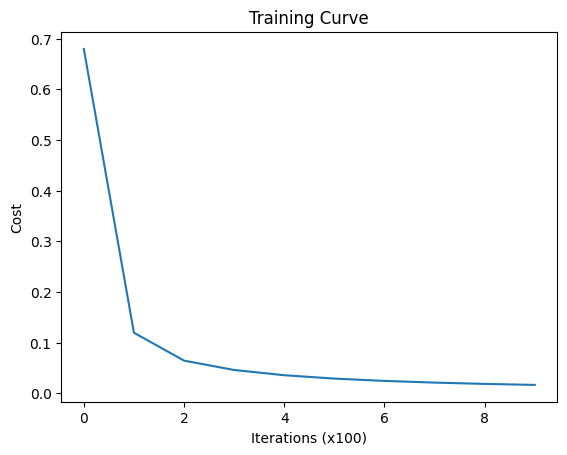

In [88]:
# Cost plot
plt.plot(Cost_history)
plt.xlabel("Iterations (x100)")
plt.ylabel("Cost")
plt.title("Training Curve")
plt.show()

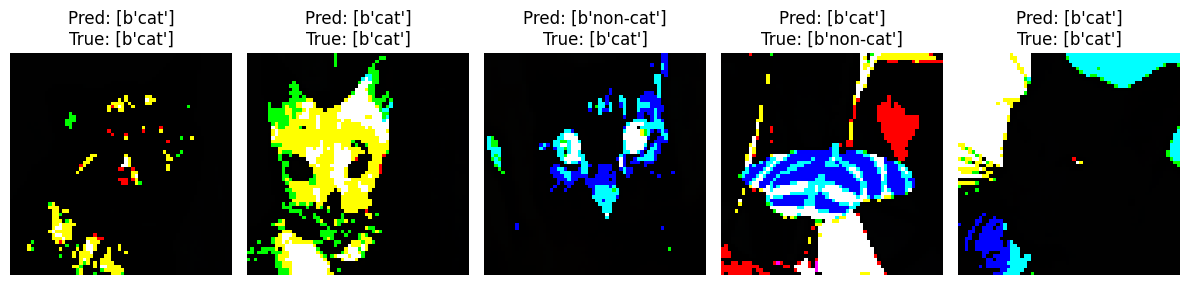

In [104]:
def show_predictions(X, y, w, b, num_samples=5):
    """
    Show few images with actual vs predicted labels
    """
    
    # Pick random samples
    indices = np.random.choice(X.shape[0], num_samples, replace=False)
    
    plt.figure(figsize=(12, 4))
    
    for i, idx in enumerate(indices):
        # Get image (flattened → reshape back)
        img = X[idx].reshape(64, 64, 3)   # adjust if your size is different
        
        # Prediction
        pred = predict(X[idx:idx+1], w, b)[0]
       
        
        true = y[idx]
        
        # Plot
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img.astype(np.uint8))   # convert back to image format
        plt.axis('off')
        classes = np.array([b'non-cat', b'cat'])
        plt.title(f"Pred: {classes[pred]}\nTrue: {classes[true]}")
        
    
    plt.tight_layout()
    plt.show()

show_predictions(X_test_original, y_test, w_final, b_final, num_samples=5)
